<a href="https://colab.research.google.com/github/vasudhabobde/Machine_Learning_Practicals/blob/main/B3_B2_32_MLDS_Practical_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("hour.csv")
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


1.Load bike_hour.csv. Display shape, column descriptions, and the target variable 'cnt' distribution.
2.Perform EDA: plot average bike demand by hour of day, season, and weather situation.
3.Part A: Simple Linear Regreesion - Select 'temp' (normalized temperature) as the single independent variable (X) and 'cnt' as target (y). Split the data (80:20) and train a Simple Linear Regression model.
4.Visualize the regression line over the scatter plot of temp vs. cnt.
6.Evaluate using MAE, MSE, RMSE, and R². Interpret the R² value.
7. Part B: Multiple Lineear Regreesion - Train a Multiple Linear Regression using all numerical features. Train and evaluate.                                8.Compare MAE and MSE, RMSE and R² of Multiple LR with Simple LR.
9.Plot actual vs. predicted bike counts for the test set for both models on the same graph. 10. Display the coefficients of the Multiple LR model. Identify which feature has the highest positive impact on bike demand and interpret it."

In [ ]:
print("Shape of dataset:", df.shape)

Shape of dataset: (17379, 17)


In [ ]:
print(df.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [ ]:
print(df.head())

   instant      dteday  season  yr  mnth  hr  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1   0        0        6           0   
1        2  2011-01-01       1   0     1   1        0        6           0   
2        3  2011-01-01       1   0     1   2        0        6           0   
3        4  2011-01-01       1   0     1   3        0        6           0   
4        5  2011-01-01       1   0     1   4        0        6           0   

   weathersit  temp   atemp   hum  windspeed  casual  registered  cnt  
0           1  0.24  0.2879  0.81        0.0       3          13   16  
1           1  0.22  0.2727  0.80        0.0       8          32   40  
2           1  0.22  0.2727  0.80        0.0       5          27   32  
3           1  0.24  0.2879  0.75        0.0       3          10   13  
4           1  0.24  0.2879  0.75        0.0       0           1    1  


In [ ]:
print(df.describe())

          instant        season            yr          mnth            hr  \
count  17379.0000  17379.000000  17379.000000  17379.000000  17379.000000   
mean    8690.0000      2.501640      0.502561      6.537775     11.546752   
std     5017.0295      1.106918      0.500008      3.438776      6.914405   
min        1.0000      1.000000      0.000000      1.000000      0.000000   
25%     4345.5000      2.000000      0.000000      4.000000      6.000000   
50%     8690.0000      3.000000      1.000000      7.000000     12.000000   
75%    13034.5000      3.000000      1.000000     10.000000     18.000000   
max    17379.0000      4.000000      1.000000     12.000000     23.000000   

            holiday       weekday    workingday    weathersit          temp  \
count  17379.000000  17379.000000  17379.000000  17379.000000  17379.000000   
mean       0.028770      3.003683      0.682721      1.425283      0.496987   
std        0.167165      2.005771      0.465431      0.639357      0.

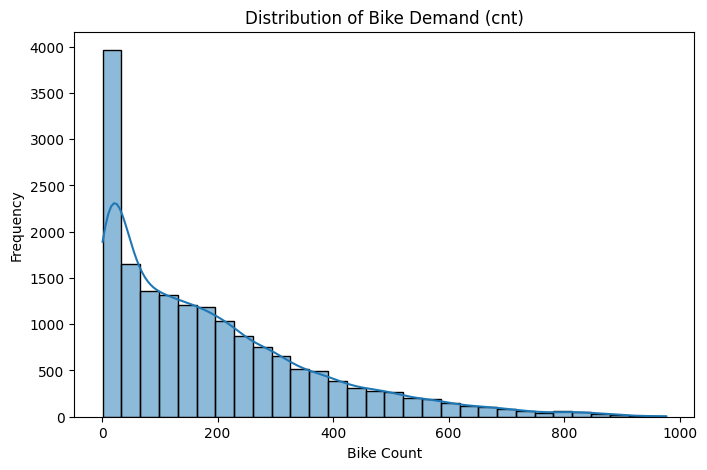

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['cnt'], bins=30, kde=True)
plt.title("Distribution of Bike Demand (cnt)")
plt.xlabel("Bike Count")
plt.ylabel("Frequency")
plt.show()

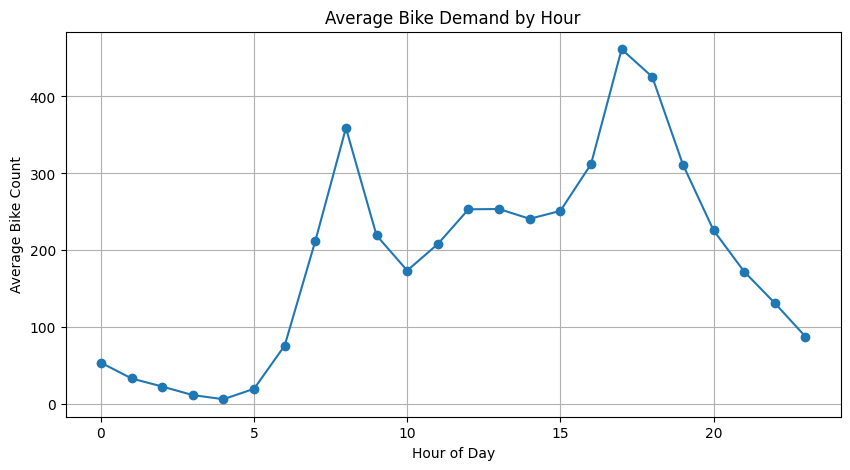

In [ ]:
hour_avg = df.groupby('hr')['cnt'].mean()

plt.figure(figsize=(10, 5))
hour_avg.plot(kind='line', marker='o')
plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Bike Count")
plt.grid()
plt.show()

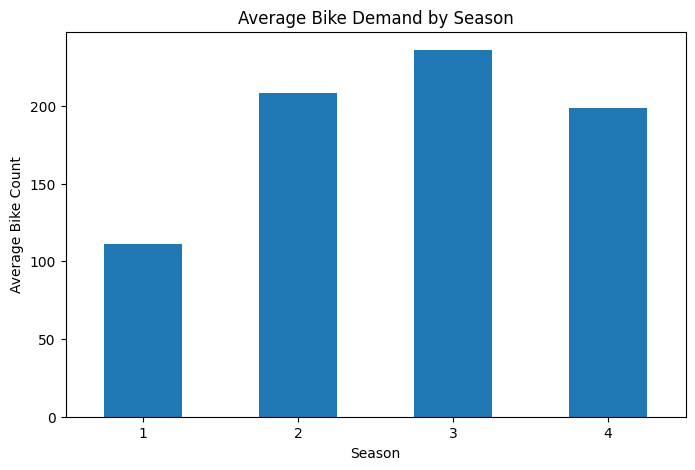

In [ ]:
season_avg = df.groupby('season')['cnt'].mean()

plt.figure(figsize=(8, 5))
season_avg.plot(kind='bar')
plt.title("Average Bike Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Bike Count")
plt.xticks(rotation=0)
plt.show()

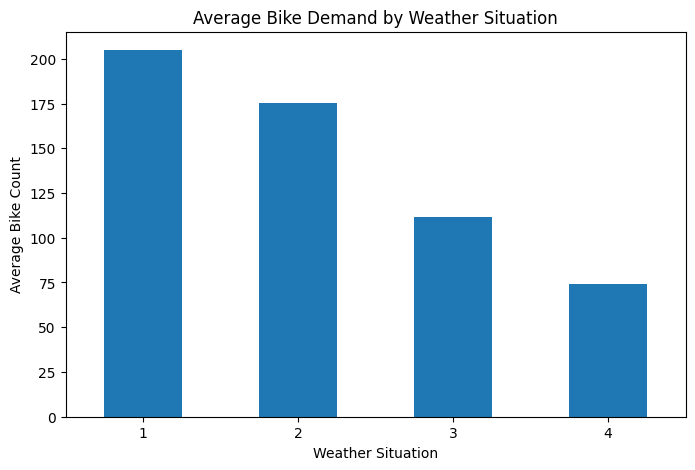

In [ ]:
weather_avg = df.groupby('weathersit')['cnt'].mean()

plt.figure(figsize=(8, 5))
weather_avg.plot(kind='bar')
plt.title("Average Bike Demand by Weather Situation")
plt.xlabel("Weather Situation")
plt.ylabel("Average Bike Count")
plt.xticks(rotation=0)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Independent and dependent variables
X = df[['temp']]
y = df['cnt']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
simple_lr = LinearRegression()

In [ ]:
simple_lr.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_simple = simple_lr.predict(X_test)

In [ ]:
print("Simple Linear Regression trained successfully.")
print("Coefficient:", simple_lr.coef_[0])
print("Intercept:", simple_lr.intercept_)

Simple Linear Regression trained successfully.
Coefficient: 380.90819317169706
Intercept: 1.1147645659039824


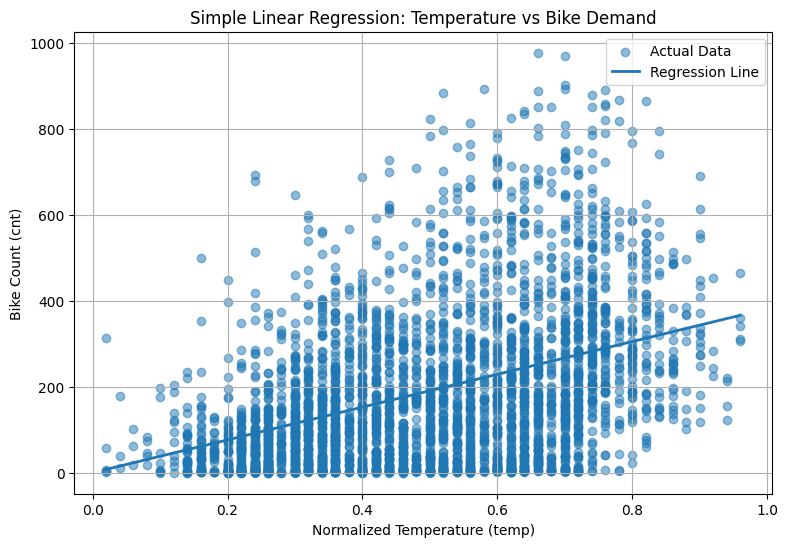

In [ ]:
plt.figure(figsize=(9, 6))

plt.scatter(X_test['temp'], y_test, alpha=0.5, label='Actual Data')

# Sort values for a clean regression line
sorted_indices = X_test['temp'].argsort()
X_sorted = X_test.iloc[sorted_indices]
y_sorted_pred = y_pred_simple[sorted_indices]

plt.plot(
    X_sorted['temp'],
    y_sorted_pred,
    linewidth=2,
    label='Regression Line'
)

plt.title("Simple Linear Regression: Temperature vs Bike Demand")
plt.xlabel("Normalized Temperature (temp)")
plt.ylabel("Bike Count (cnt)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_simple = mean_absolute_error(y_test, y_pred_simple)
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Simple Linear Regression Results")
print("--------------------------------")
print("MAE  :", mae_simple)
print("MSE  :", mse_simple)
print("RMSE :", rmse_simple)
print("R²   :", r2_simple)

Simple Linear Regression Results
--------------------------------
MAE  : 123.1528738977561
MSE  : 26363.544525542813
RMSE : 162.36854536991706
R²   : 0.16743401039637895


In [ ]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()

# Remove target variable
numerical_features.remove('cnt')

In [ ]:
print("Features used:")
print(numerical_features)

X_multi = df[numerical_features]
y_multi = df['cnt']

Features used:
['instant', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered']


In [ ]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)


In [ ]:
multiple_lr = LinearRegression()

In [ ]:
multiple_lr.fit(X_train_m, y_train_m)

LinearRegression()

In [ ]:
y_pred_multi = multiple_lr.predict(X_test_m)

print("\nMultiple Linear Regression trained successfully.")


Multiple Linear Regression trained successfully.


In [ ]:
mae_multi = mean_absolute_error(y_test_m, y_pred_multi)
mse_multi = mean_squared_error(y_test_m, y_pred_multi)
rmse_multi = np.sqrt(mse_multi)
r2_multi = r2_score(y_test_m, y_pred_multi)

print("Multiple Linear Regression Results")
print("-----------------------------------")
print("MAE  :", mae_multi)
print("MSE  :", mse_multi)
print("RMSE :", rmse_multi)
print("R²   :", r2_multi)

Multiple Linear Regression Results
-----------------------------------
MAE  : 2.4751359062312176e-11
MSE  : 8.209297810782344e-22
RMSE : 2.8651872208954066e-11
R²   : 1.0


In [ ]:
comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Simple Linear Regression': [
        mae_simple,
        mse_simple,
        rmse_simple,
        r2_simple
    ],
    'Multiple Linear Regression': [
        mae_multi,
        mse_multi,
        rmse_multi,
        r2_multi
    ]
})

display(comparison)

,Metric,Simple Linear Regression,Multiple Linear Regression
0,MAE,123.152874,2.475136e-11
1,MSE,26363.544526,8.209298e-22
2,RMSE,162.368545,2.865187e-11
3,R²,0.167434,1.000000e+00


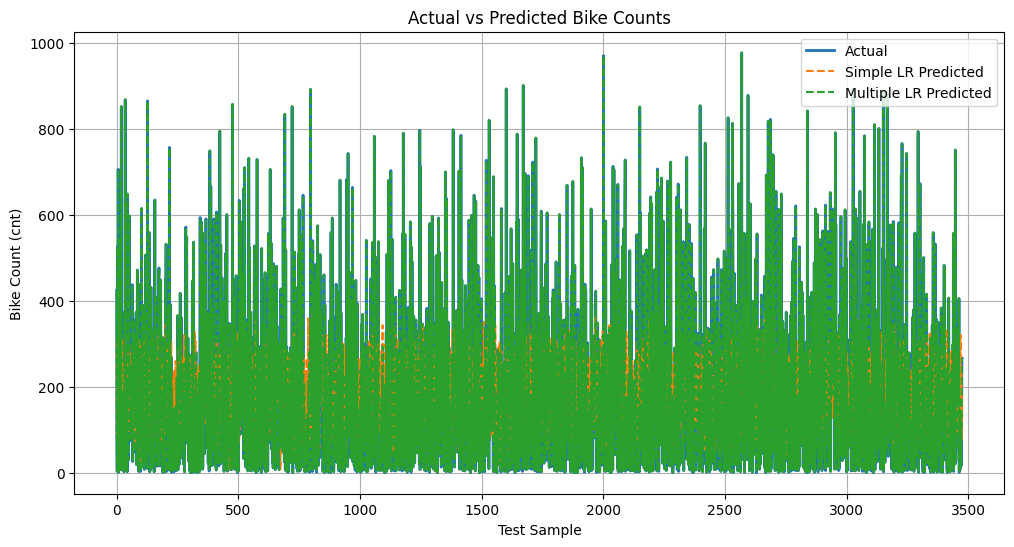

In [ ]:
plt.figure(figsize=(12, 6))

# Actual values
plt.plot(
    range(len(y_test)),
    y_test.values,
    label='Actual',
    linewidth=2
)

# Simple LR predictions
plt.plot(
    range(len(y_pred_simple)),
    y_pred_simple,
    label='Simple LR Predicted',
    linestyle='--'
)

# Multiple LR predictions
plt.plot(
    range(len(y_pred_multi)),
    y_pred_multi,
    label='Multiple LR Predicted',
    linestyle='--'
)

plt.title("Actual vs Predicted Bike Counts")
plt.xlabel("Test Sample")
plt.ylabel("Bike Count (cnt)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    'Feature': numerical_features,
    'Coefficient': multiple_lr.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

display(coefficients)

,Feature,Coefficient
13,casual,1.000000e+00
14,registered,1.000000e+00
7,workingday,4.137089e-14
5,holiday,1.862818e-14
0,instant,5.756782e-15
11,hum,9.762394e-16
6,weekday,-1.500427e-15
4,hr,-1.885861e-15
12,windspeed,-2.753223e-15
3,mnth,-3.101686e-15


In [ ]:
highest_positive = coefficients.iloc[0]

print("Feature with highest positive impact:")
print("Feature:", highest_positive['Feature'])
print("Coefficient:", highest_positive['Coefficient'])

Feature with highest positive impact:
Feature: casual
Coefficient: 1.0


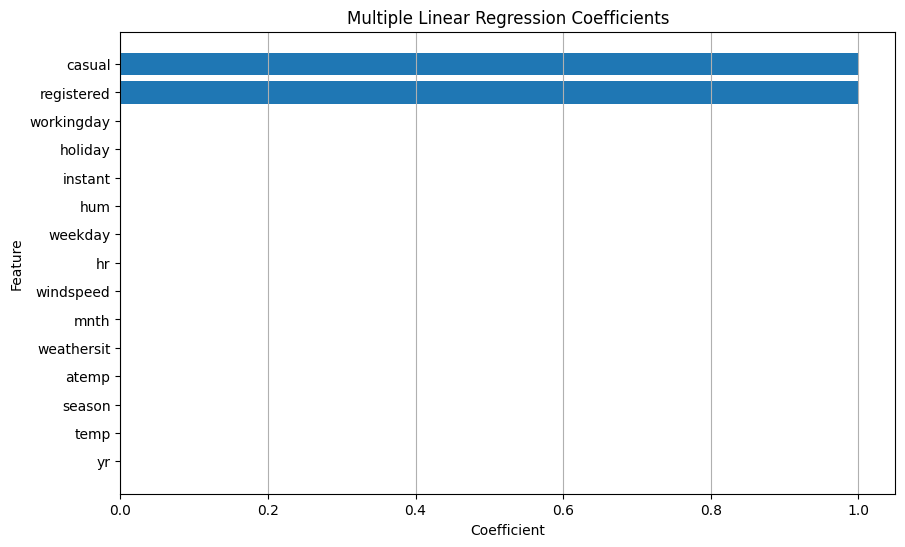

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    coefficients['Feature'],
    coefficients['Coefficient']
)

plt.title("Multiple Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.grid(axis='x')
plt.show()